This notebook needs TensorFlow (`pip install tensorflow==2.21.0`, already in the repo's requirements.txt).

In [1]:
# =============================================================================
# Standard Libraries
# =============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'  # hide warning

# =============================================================================
# Scikit-learn for Preprocessing, Model Selection, and Metrics
# =============================================================================
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    precision_recall_curve, 
    auc, 
    classification_report, 
    confusion_matrix,
    # Potentially roc_auc_score if comparing with binary classification from errors
)

# =============================================================================
# TensorFlow / Keras for Autoencoder
# =============================================================================
import tensorflow as tf # Good practice to import tf itself
from tensorflow.keras.models import Model, load_model
from tensorflow.keras.layers import Input, Dense, LeakyReLU, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adam # Explicitly import optimizer

In [2]:
# Repo helper (not one of the book's listings): creditcard.csv is stored zipped in this
# folder because the raw CSV (~150 MB) exceeds GitHub's 100 MB file limit.
# Extract it once so that listing 8.1 can read "creditcard.csv" as printed.
# Data: "Credit Card Fraud Detection", Machine Learning Group - ULB (with Worldline),
# www.kaggle.com/datasets/mlg-ulb/creditcardfraud (ODbL 1.0 database / DbCL 1.0 contents)
import os
import zipfile

if not os.path.exists("creditcard.csv") and os.path.exists("creditcard.csv.zip"):
    with zipfile.ZipFile("creditcard.csv.zip") as zf:
        zf.extract("creditcard.csv")
    print("Extracted creditcard.csv from creditcard.csv.zip")

Extracted creditcard.csv from creditcard.csv.zip


Credit Card Fraud dataset loaded successfully.
--------------------------------------------------
First 5 rows of the dataset:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0



--------------------------------------------------
Dataset Shape (rows, columns): (284807, 31)
--------------------------------------------------
Class distribution (0: Legitimate, 1: Fraud):
Class
0    284315
1       492
Name: count, dtype: int64

Proportion of total:


,Proportion,proportion
0,0,0.998273
1,1,0.001727


--------------------------------------------------


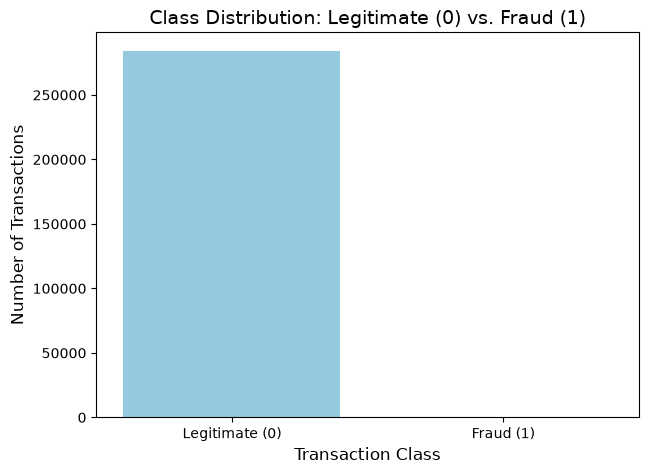

In [3]:
# Define the path to the dataset
DATA_PATH = "creditcard.csv" 

try:
    df = pd.read_csv(DATA_PATH) 
    print("Credit Card Fraud dataset loaded successfully.")
    print("--------------------------------------------------")
    print("First 5 rows of the dataset:")
    display(df.head()) 
    print("\n--------------------------------------------------")
    print(f"Dataset Shape (rows, columns): {df.shape}") 
    print("--------------------------------------------------")
    print("Class distribution (0: Legitimate, 1: Fraud):")
    class_counts = df['Class'].value_counts() 
    class_proportion = df['Class'].value_counts(normalize=True) 
    print(class_counts)
    print("\nProportion of total:")
    display(class_proportion.reset_index().rename(
        columns={'index': 'Class_Label', 'Class': 'Proportion'} 
    ))
    print("--------------------------------------------------")
    
    plt.figure(figsize=(7, 5))
    custom_palette = {0: "skyblue", 1: "salmon"}
    sns.countplot(x='Class', data=df, hue='Class', palette=custom_palette, legend=False) 
    plt.title('Class Distribution: Legitimate (0) vs. Fraud (1)', fontsize=14)
    plt.xlabel('Transaction Class', fontsize=12)
    plt.ylabel('Number of Transactions', fontsize=12)
    plt.xticks([0, 1], ['Legitimate (0)', 'Fraud (1)']) 
    plt.show()
    
except FileNotFoundError:
    print(f"Error: '{DATA_PATH}' was not found. Please ensure the file is in the correct path relative to your notebook.")
    df = None

In [4]:
if df is not None:
    df_proc = df.copy() # Work on a copy

    # Scale 'Amount' and 'Time' features
    scaler = StandardScaler()
    df_proc['scaled_amount'] = scaler.fit_transform(df_proc['Amount'].values.reshape(-1, 1))
    df_proc['scaled_time'] = scaler.fit_transform(df_proc['Time'].values.reshape(-1, 1))
    df_proc.drop(['Time', 'Amount'], axis=1, inplace=True)

    # Reorder columns to move 'Class' to the end
    if 'Class' in df_proc.columns:
        cols = [col for col in df_proc.columns if col != 'Class'] + ['Class']
        df_proc = df_proc[cols]

    # Separate features (X) and the target variable (y)
    X = df_proc.drop('Class', axis=1)
    y = df_proc['Class']

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42, stratify=y
    )

    print("Data preprocessing (scaling and splitting) completed.")
    print("--------------------------------------------------")
    print(f"Shape of X_train: {X_train.shape}, Shape of y_train: {y_train.shape}")
    print(f"Shape of X_test: {X_test.shape}, Shape of y_test: {y_test.shape}")
    print("--------------------------------------------------")
    print("Fraud proportion in y_train (original, imbalanced):")
    display(y_train.value_counts(normalize=True))
    print("--------------------------------------------------")
    print("Fraud proportion in y_test (original, imbalanced):")
    display(y_test.value_counts(normalize=True))
    print("--------------------------------------------------")

else:
    print("DataFrame 'df' was not loaded. Cannot proceed with preprocessing.")

Data preprocessing (scaling and splitting) completed.
--------------------------------------------------
Shape of X_train: (199364, 30), Shape of y_train: (199364,)
Shape of X_test: (85443, 30), Shape of y_test: (85443,)
--------------------------------------------------
Fraud proportion in y_train (original, imbalanced):


Class
0    0.998275
1    0.001725
Name: proportion, dtype: float64

--------------------------------------------------
Fraud proportion in y_test (original, imbalanced):


Class
0    0.998268
1    0.001732
Name: proportion, dtype: float64

--------------------------------------------------


In [5]:
# Ensure X_train, X_test, y_train, y_test are available from previous sections (e.g., Listing 8.2)
# X_train and X_test should already be scaled from earlier preprocessing.

# Create a training set for the autoencoder using only legitimate transactions from X_train
X_train_autoencoder_legit = X_train[y_train == 0]

# For evaluation, X_test (containing both classes) and y_test (true labels) will be used.
X_test_legit_for_ae_eval = X_test[y_test == 0]
X_test_fraud_for_ae_eval = X_test[y_test == 1]

print(f"Shape of X_train_autoencoder_legit (for AE training): {X_train_autoencoder_legit.shape}")
print(f"Shape of X_test (for AE prediction and evaluation): {X_test.shape}")
print(f"Number of legitimate samples in X_test for AE eval: {X_test_legit_for_ae_eval.shape[0]}")
print(f"Number of fraudulent samples in X_test for AE eval: {X_test_fraud_for_ae_eval.shape[0]}")

Shape of X_train_autoencoder_legit (for AE training): (199020, 30)
Shape of X_test (for AE prediction and evaluation): (85443, 30)
Number of legitimate samples in X_test for AE eval: 85295
Number of fraudulent samples in X_test for AE eval: 148


In [6]:
# Ensure X_train_autoencoder_legit is defined from Listing 8.9
input_dim = X_train_autoencoder_legit.shape[1]
encoding_dim = 14 # Example: can be tuned

# --- Input Layer ---
input_layer = Input(shape=(input_dim,), name="Input_Layer")

# --- Encoder ---
# Layer 1
encoded = Dense(encoding_dim * 2, name="Encoder_Dense_1")(input_layer)
encoded = BatchNormalization(name="Encoder_BN_1")(encoded)
encoded = LeakyReLU(negative_slope=0.1, name="Encoder_LeakyReLU_1")(encoded)

# Layer 2 (Bottleneck - Encoded Representation)
encoded_representation = Dense(encoding_dim, name="Encoded_Representation")(encoded)
encoded_output = BatchNormalization(name="Encoder_BN_Bottleneck")(encoded_representation)
encoded_output = LeakyReLU(negative_slope=0.1, name="Encoder_Output_LeakyReLU")(encoded_output)

# --- Decoder ---
# Layer 1 (mirrors Encoder Layer 1 in reverse)
decoded = Dense(encoding_dim * 2, name="Decoder_Dense_1")(encoded_output)
decoded = BatchNormalization(name="Decoder_BN_1_Decoder")(decoded)
decoded = LeakyReLU(negative_slope=0.1, name="Decoder_LeakyReLU_1_Decoder")(decoded)

# Output Layer (reconstructs to original input dimension)
reconstructed_input = Dense(input_dim, activation='linear', name="Output_Reconstruction")(decoded)

# --- Autoencoder Model (Encoder + Decoder) ---
autoencoder_model = Model(inputs=input_layer, outputs=reconstructed_input)

# Compile the autoencoder
autoencoder_model.compile(optimizer=Adam(learning_rate=0.0001),
                          loss='mean_squared_error',
                          metrics=['mae'])

print("Autoencoder architecture defined and compiled.")
autoencoder_model.summary()

Autoencoder architecture defined and compiled.


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ Input_Layer (InputLayer)        │ (None, 30)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_Dense_1 (Dense)         │ (None, 28)             │           868 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_BN_1                    │ (None, 28)             │           112 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_LeakyReLU_1 (LeakyReLU) │ (None, 28)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoded_Representation (Dense)  │ (None, 14)             │           406 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_BN_Bottleneck           │ (None, 14)             │            56 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Encoder_Output_LeakyReLU        │ (None, 14)             │             0 │
│ (LeakyReLU)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_Dense_1 (Dense)         │ (None, 28)             │           420 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_BN_1_Decoder            │ (None, 28)             │           112 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Decoder_LeakyReLU_1_Decoder     │ (None, 28)             │             0 │
│ (LeakyReLU)                     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Output_Reconstruction (Dense)   │ (None, 30)             │           870 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,844 (11.11 KB)

 Trainable params: 2,704 (10.56 KB)

 Non-trainable params: 140 (560.00 B)


Training autoencoder on 159216 legitimate samples, validating on 39804 legitimate samples...
Epoch 1/50


  1/311 ━━━━━━━━━━━━━━━━━━━━ 3:44 725ms/step - loss: 1.5754 - mae: 0.8292

 90/311 ━━━━━━━━━━━━━━━━━━━━ 0s 565us/step - loss: 1.5526 - mae: 0.8188  

203/311 ━━━━━━━━━━━━━━━━━━━━ 0s 497us/step - loss: 1.4351 - mae: 0.7936

311/311 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 1.3575 - mae: 0.7711 - val_loss: 1.1284 - val_mae: 0.7000


...

111/311 ━━━━━━━━━━━━━━━━━━━━ 0s 457us/step - loss: 0.2046 - mae: 0.3049

222/311 ━━━━━━━━━━━━━━━━━━━━ 0s 455us/step - loss: 0.2005 - mae: 0.3026

311/311 ━━━━━━━━━━━━━━━━━━━━ 0s 583us/step - loss: 0.2094 - mae: 0.3034 - val_loss: 0.1794 - val_mae: 0.2872


Restoring model weights from the end of the best epoch: 50.



Autoencoder training completed.


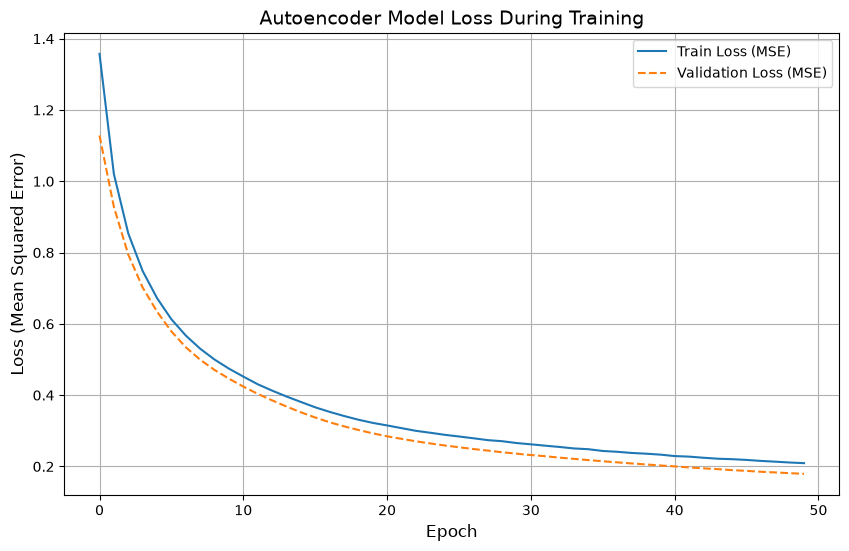

In [7]:
# Ensure X_train_autoencoder_legit is available from Listing 8.9

# Splitting legitimate training data (X_train_autoencoder_legit) for AE's own validation during training
X_train_ae_actual_fit, X_val_ae_actual_fit = train_test_split(
    X_train_autoencoder_legit, test_size=0.2, random_state=42
) # A

num_epochs_ae = 50
batch_size_ae = 512

# Callbacks
early_stopper_ae = EarlyStopping(monitor='val_loss', patience=10, verbose=1, restore_best_weights=True)
# It's good practice to save the best model.
model_checkpoint_ae = ModelCheckpoint(
    'best_autoencoder_model_ch8.keras', monitor='val_loss', save_best_only=True, verbose=0
)

print(f"\nTraining autoencoder on {X_train_ae_actual_fit.shape[0]} legitimate samples, validating on {X_val_ae_actual_fit.shape[0]} legitimate samples...")
history_ae = autoencoder_model.fit(
    X_train_ae_actual_fit, X_train_ae_actual_fit, # Input and Target are the same
    epochs=num_epochs_ae,
    batch_size=batch_size_ae,
    shuffle=True,
    validation_data=(X_val_ae_actual_fit, X_val_ae_actual_fit), # Using the split validation set
    callbacks=[early_stopper_ae, model_checkpoint_ae], # Include checkpointing
    verbose=1
).history

print("\nAutoencoder training completed.")

# Plot training & validation loss
plt.figure(figsize=(10, 6))
plt.plot(history_ae['loss'], label='Train Loss (MSE)', linestyle='-') # A solid line for training loss
plt.plot(history_ae['val_loss'], label='Validation Loss (MSE)', linestyle='--') # A dashed line for validation loss
plt.title('Autoencoder Model Loss During Training', fontsize=14)
plt.ylabel('Loss (Mean Squared Error)', fontsize=12)
plt.xlabel('Epoch', fontsize=12)
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

In [8]:
test_reconstructions = autoencoder_model.predict(X_test)
mse_per_instance_test = np.mean(np.power(X_test - test_reconstructions, 2), axis=1)
mae_per_instance_test = np.mean(np.abs(X_test - test_reconstructions), axis=1)

reconstruction_error_df_test = pd.DataFrame({
    'mse': mse_per_instance_test,
    'mae': mae_per_instance_test,
    'true_class': y_test
})

print("\nReconstruction errors calculated for the test set.")
print("First 5 rows of reconstruction errors with true classes:")
display(reconstruction_error_df_test.head())
print("\nSummary statistics of reconstruction errors, grouped by true class:")
display(reconstruction_error_df_test.groupby('true_class')[['mse', 'mae']].describe())

   1/2671 ━━━━━━━━━━━━━━━━━━━━ 1:10 26ms/step

 348/2671 ━━━━━━━━━━━━━━━━━━━━ 0s 144us/step 

 715/2671 ━━━━━━━━━━━━━━━━━━━━ 0s 140us/step

1085/2671 ━━━━━━━━━━━━━━━━━━━━ 0s 139us/step

1457/2671 ━━━━━━━━━━━━━━━━━━━━ 0s 138us/step

...

2671/2671 ━━━━━━━━━━━━━━━━━━━━ 0s 146us/step



Reconstruction errors calculated for the test set.
First 5 rows of reconstruction errors with true classes:


,mse,mae,true_class
186882,0.366249,0.470725,0
165754,0.079515,0.233161,0
235285,0.319242,0.463105,0
101271,0.114490,0.236806,0
5832,0.047747,0.175662,0



Summary statistics of reconstruction errors, grouped by true class:


mse                                                      \
              count       mean        std       min       25%       50%   
true_class                                                                
0           85295.0   0.178249   0.627291  0.011996  0.075801  0.117404   
1             148.0  16.465994  20.981507  0.041108  2.942153  7.210398   

                                      mae                                \
                  75%        max    count      mean       std       min   
true_class                                                                
0            0.192221  42.006735  85295.0  0.286421  0.136273  0.075987   
1           20.625589  82.104480    148.0  2.260868  1.656309  0.154360   

                                                    
                 25%       50%       75%       max  
true_class                                          
0           0.207297  0.258944  0.333600  4.487548  
1           1.149704  1.840143  3.156227  6.881490

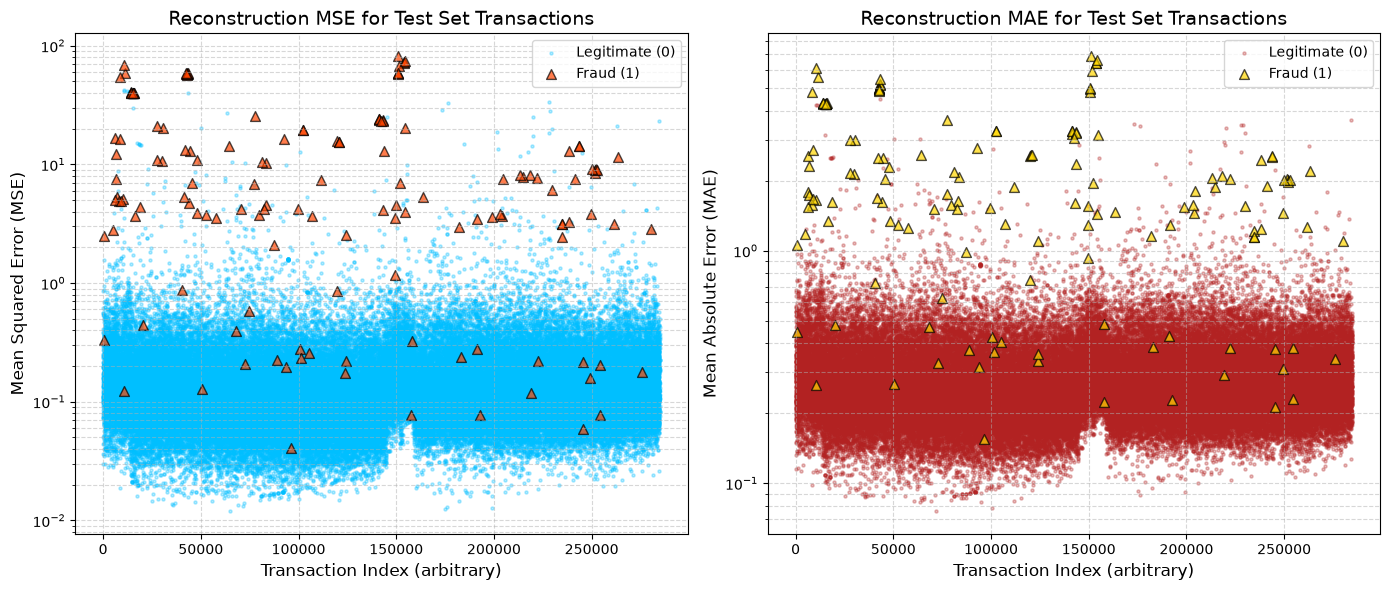

In [9]:
df_legit_errors = reconstruction_error_df_test[reconstruction_error_df_test['true_class'] == 0]
df_fraud_errors = reconstruction_error_df_test[reconstruction_error_df_test['true_class'] == 1]
plt.figure(figsize=(14, 6))

# Plotting MSE
plt.subplot(1, 2, 1)
# Scatter plot for legitimate transactions
plt.scatter(df_legit_errors.index, df_legit_errors['mse'],
            label='Legitimate (0)', marker='o', s=5, alpha=0.3, c='deepskyblue')
# Scatter plot for fraudulent transactions
plt.scatter(df_fraud_errors.index, df_fraud_errors['mse'],
            label='Fraud (1)', marker='^', s=50, alpha=0.7, c='orangered', edgecolors='black')
plt.title('Reconstruction MSE for Test Set Transactions', fontsize=14)
plt.xlabel('Transaction Index (arbitrary)', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.yscale('log')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, which="both", ls="--", alpha=0.5)

# Plotting MAE (similar approach)
plt.subplot(1, 2, 2)
plt.scatter(df_legit_errors.index, df_legit_errors['mae'],
            label='Legitimate (0)', marker='o', s=5, alpha=0.3, c='firebrick')
plt.scatter(df_fraud_errors.index, df_fraud_errors['mae'],
            label='Fraud (1)', marker='^', s=50, alpha=0.7, c='gold', edgecolors='black')
plt.title('Reconstruction MAE for Test Set Transactions', fontsize=14)
plt.xlabel('Transaction Index (arbitrary)', fontsize=12)
plt.ylabel('Mean Absolute Error (MAE)', fontsize=12)
plt.yscale('log')
plt.legend(loc='upper right', fontsize=10)
plt.grid(True, which="both", ls="--", alpha=0.5)

plt.tight_layout()
plt.show()